# CS448 - Lab 7: Pitch tracking and modifications

In [1]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

# Make a sound player function that plays array "x" with a sample rate "rate", and labels it with "label"
def sound_player( x, rate=8000, label=''):
    from IPython.display import display, Audio, HTML
    display( HTML( 
    '<style> table, th, td {border: 0px; }</style> <table><tr><td>' + label + 
    '</td><td>' + Audio( x, rate=rate)._repr_html_()[3:] + '</td></tr></table>'
    ))


## Part 1: Making a pitch tracker

In this section we will design a pitch tracker. We will apply it on ```beauty.wav```


We want to find the pitch of the singing over time, as well as if the sound is pitched or not at any point in time. To do so we will design an autocorrelation pitch tracker.
Do the following:
1. Perform an STFT of the sound
2. Using the DFT representation of each frame compute the frame’s autocorrelation
3. Invert each frame’s autocorrelation back to the time domain
4. Find the first peak after the main peak (the main peak will be at address 0)
    - We will only look for pitches between 100 and 300Hz
	- Which means that you only need to look for a peak at a specific address range
5. If the peak is more than 70% of the main peak we have a pitched frame
	- Otherwise it is an un-pitched frame
	
Plot the pitch value over time and see if it correlates with what you are hearing (the lecture slides have the correct plot for reference).


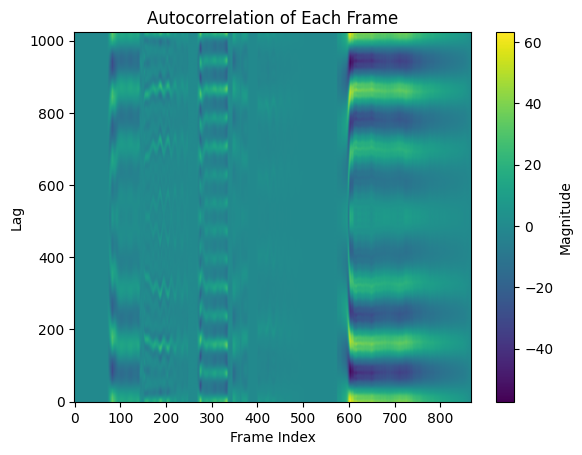

In [28]:
# # YOUR CODE HERE

beauty, sr = sf.read("beauty.wav")

def stft( input_sound, dft_size, hop_size, window):
    input_sound_length = len(input_sound)
    num_frames = 1 + (input_sound_length - dft_size) // hop_size
    spectrogram = np.zeros((dft_size // 2 + 1, num_frames), dtype=np.complex64)
    for frame in range(num_frames):
        start = frame * hop_size
        end = start + dft_size
        segment = input_sound[start:end] * window
        spectrum = np.fft.rfft(segment, n=dft_size)
        spectrogram[:, frame] = spectrum  
    return spectrogram

def istft( stft_output, dft_size, hop_size, window):
    number_frames = stft_output.shape[1]
    output_length = (number_frames - 1) * hop_size + dft_size
    x = np.zeros(output_length)
    
    for frame in range(number_frames):
        start = frame * hop_size
        end = start + dft_size
        windowed_frame = np.fft.irfft(stft_output[:, frame], n=dft_size)
        x[start:end] += windowed_frame * window
    
    return x

# dft_size = 1024
# hop_size = 512
# window = np.sqrt(np.hanning(dft_size))
# x = stft(beauty, dft_size,hop_size,window)
# xconj = np.conj(x)

# c = x*xconj
# ct = np.fft.irfft(c,n=1024,axis=0)
#     # istft(c,dft_size,hop_size,window)
# plt.imshow(ct, aspect='auto', origin='lower')
# plt.xlabel('Frame Index')
# plt.ylabel('Lag')
# plt.title('Autocorrelation of Each Frame')
# plt.colorbar(label='Magnitude')
# plt.show()
# # for i in range(x.shape[1]):
# #     c 
# brange = sr // np.array([300,100])
# # print(brange)
# peaki = np.argmax(ct[brange[0]:brange[1],],axis=0)+brange[0]
# peakm = np.max(ct,axis=0)
# peakv = ct[peaki,np.arange(ct.shape[1])]
# unvoiced = peakv < .7 * peakm
x, fs=sf.read('beauty.wav')
X = stft(x, dft_size=1024, hop_size=512, window=np.hanning(1024)) 
Y=X*np.conj(X)
y=np.fft.irfft(Y, n=1024, axis=0)

# Didn't bother swapping the top and bottom halves; they are symmetric, so it doesn't matter. 
plt.imshow(y, aspect='auto', origin='lower')
plt.xlabel('Frame Index')
plt.ylabel('Lag')
plt.title('Autocorrelation of Each Frame')
plt.colorbar(label='Magnitude')
plt.show()

range_bin=fs//np.array([300,100])
y_peak=np.argmax(y[range_bin[0]:range_bin[1],:], axis=0)+range_bin[0]
y_peak_main=np.max(y, axis=0)
y_peak_value=y[y_peak, np.arange(y.shape[1])]
unvoiced=y_peak_value < 0.7*y_peak_main


(868,) (868,)


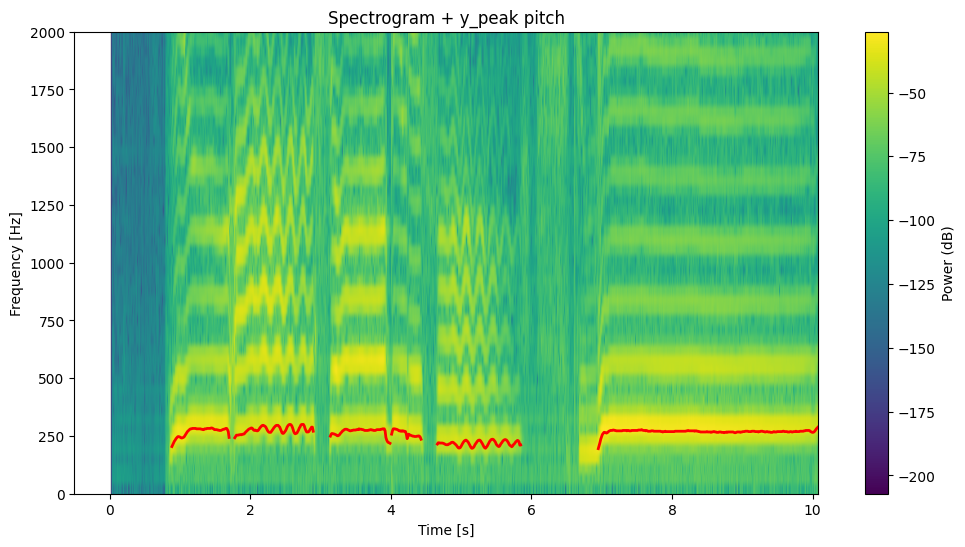

In [30]:
NFFT = 1024
freqs = (1/(y_peak/fs)) # period in samples to time, and then freq in Hz.

hop = 512
t = np.linspace(0, X.shape[1] * hop / fs, X.shape[1])

print(freqs.shape, t.shape)
freqs[unvoiced]=np.nan # remove unvoiced part from the figure

plt.figure(figsize=(12, 6))
plt.specgram(x, NFFT=1024, Fs=fs, noverlap=512, cmap='viridis')
plt.plot(t, freqs, 'r-', linewidth=2)      # overlay pitch track
plt.ylim(0, 2000)        # zoom to vocal range, optional
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.title('Spectrogram + y_peak pitch')
plt.colorbar(label='Power (dB)')

## Part 2. Changing pitch (PSOLA-ish algorithm)

We will now correct the pitch of that last horrible note. We will use the zero crossing method to find where the periods are and then we will shift them appropriately to create a pitch of 274Hz.

1. Get samples from 303,000 to 445,000 which is the horrible part.

2. Lowpass filter to facilitate the zero crossing finding

    - Pick an appropriate cutoff frequency that will help
    - Use the ```scipy.signal.filtfilt()``` function which will not time-shift the input

3. There are two zero crossing points per period. So, keep only every other points.     

    - Now each zero crossing point should be the start of each period

4. For each period get the signal from the previous period’s start till this period’s end

5. Window that signal with a Hann window to remove any discontinuities

6. Overlap add each of the above at a rate appropriate for 274Hz

    - How many patterns are needed in a second to sound like a 274 Hz pitch?

Play the sound, does it sound more in tune? (it better!)

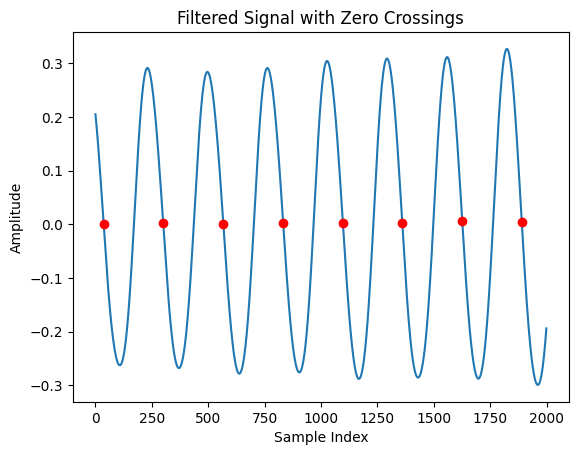

In [ ]:
# YOUR CODE HERE
from scipy.signal import butter, filtfilt
xbad = x[303000:445000]

cutoff = 500
b,a = butter( 4, cutoff, fs=fs)
xlp = filtfilt(b, a, xbad)

zeros = np.where(np.diff(np.sign(xlp)))[0]
zeros = zeros[::2]

plt.plot(xlp[:2000])  # Plot a portion of the filtered signal
plt.plot(zeros[zeros<2000], xlp[:2000][zeros[zeros<2000]], 'ro')
plt.title('Filtered Signal with Zero Crossings')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

periods = []
for i in range(1,len(zeros)):
    start = zeros[i-1]
    end = zeros[i]
    periods.append(xbad[start:end])

wperiods = [(period * np.hanning(len(period)) for period in periods)]

